In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

### Extract Data

In [5]:
df = pd.read_csv('C:\\Users\\Windows 10\\OneDrive\\Desktop\\Coding\\Stat Comp\\Project\\Data\\mag7_nasdaq_cleaned.csv')
df.head()

,Date_Cleaned,AAPL_Cleaned,AMZN_Cleaned,WTI_Crude_Oil_Cleaned,Dollar_Index_Cleaned,COMEX_Gold_Cleaned,GOOGL_Cleaned,META_Cleaned,MSFT_Cleaned,NVDA_Cleaned,Treasury_Inflation_Cleaned,TSLA_Cleaned,Nasdaq_Cleaned,VIX_Fear_Index_Cleaned
0,2021-01-04,125.856697,159.331497,47.619999,89.879997,1944.699951,85.659279,267.074463,208.406540,13.076725,105.337845,243.256668,12698.450195,26.969999
1,2021-01-05,127.412788,160.925507,49.930000,89.440002,1952.699951,86.350075,269.090332,208.607574,13.367160,105.304878,245.036667,12818.959961,25.340000
2,2021-01-06,123.123856,156.919006,50.630001,89.529999,1906.900024,85.498001,261.483429,203.198547,12.579124,104.991623,251.993332,12740.790039,25.070000
3,2021-01-07,127.325218,158.108002,50.830002,89.830002,1912.300049,88.051712,266.875793,208.980942,13.306579,104.925713,272.013336,13067.480469,22.370001
4,2021-01-08,128.424225,159.134995,52.240002,90.099998,1834.099976,89.217392,265.713898,210.254196,13.239515,104.513542,293.339996,13201.980469,21.559999


In [6]:
df_returns = pd.read_csv('C:\\Users\\Windows 10\\OneDrive\\Desktop\\Coding\\Stat Comp\\Project\\Data\\mag7_nasdaq_returns.csv')
df_returns.drop(columns=['Unnamed: 0'], inplace=True)
df_returns.head()

,AAPL_Return,AMZN_Return,WTI_Crude_Oil_Return,Dollar_Index_Return,COMEX_Gold_Return,GOOGL_Return,META_Return,MSFT_Return,NVDA_Return,Treasury_Inflation_Return,TSLA_Return,Nasdaq_Return,VIX_Fear_Index_Return,Date_Return
0,0.012364,0.010004,0.048509,-0.004895,0.004114,0.008064,0.007548,0.000965,0.022210,-0.000313,0.007317,0.009490,-0.060437,2021-01-05
1,-0.033662,-0.024897,0.014020,0.001006,-0.023455,-0.009868,-0.028269,-0.025929,-0.058953,-0.002975,0.028390,-0.006098,-0.010655,2021-01-06
2,0.034123,0.007577,0.003950,0.003351,0.002832,0.029869,0.020622,0.028457,0.057830,-0.000628,0.079447,0.025641,-0.107698,2021-01-07
3,0.008631,0.006496,0.027740,0.003006,-0.040893,0.013239,-0.004354,0.006093,-0.005040,-0.003928,0.078403,0.010293,-0.036209,2021-01-08
4,-0.023249,-0.021519,0.000191,0.004883,0.008451,-0.023106,-0.040102,-0.009699,0.025967,-0.002130,-0.078214,-0.012540,0.116883,2021-01-11


### Describe Basic Statistics Measure

In [7]:
# Summary statistics from Total 5 Years
### For Assets Values
df.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
AAPL_Cleaned,179.388218,39.990199,113.334122,285.922455
AMZN_Cleaned,163.474199,40.352608,81.820000,254.000000
WTI_Crude_Oil_Cleaned,76.092832,12.950562,47.619999,123.699997
Dollar_Index_Cleaned,100.990835,5.439877,89.440002,114.110001
COMEX_Gold_Cleaned,2275.714715,669.532545,1623.300049,4529.100098
GOOGL_Cleaned,145.596341,45.526542,82.804359,323.228577
META_Cleaned,386.845488,186.866014,88.293243,788.823792
MSFT_Cleaned,342.100633,89.202662,203.198547,539.825256
NVDA_Cleaned,67.281599,57.455105,11.212902,207.028473
Treasury_Inflation_Cleaned,103.952693,4.190201,95.557091,111.774773


In [8]:
# Transform Date to Year for Grouping
df_returns['Date_Return'] = pd.to_datetime(df_returns['Date_Return'])
df_returns['Year_Return'] = df_returns['Date_Return'].dt.year

In [9]:
# Summary Mean Returns from Any Years
df_GM = df_returns.groupby('Year_Return').mean()
df_GM.drop(columns=['Date_Return'], inplace=True)
df_GM

,AAPL_Return,AMZN_Return,WTI_Crude_Oil_Return,Dollar_Index_Return,COMEX_Gold_Return,GOOGL_Return,META_Return,MSFT_Return,NVDA_Return,Treasury_Inflation_Return,TSLA_Return,Nasdaq_Return,VIX_Fear_Index_Return
Year_Return,,,,,,,,,,,,,
2021,0.001409,0.000295,0.002070,0.000254,-0.000205,0.002181,0.001064,0.001855,0.003625,0.000220,0.002061,0.000896,0.002387
2022,-0.000970,-0.002232,0.000721,0.000332,0.000030,-0.001678,-0.003223,-0.001063,-0.001991,-0.000504,-0.003293,-0.001398,0.003197
2023,0.001678,0.002588,-0.000226,-0.000076,0.000536,0.002022,0.004621,0.001960,0.005338,0.000159,0.003387,0.001503,-0.000720
2024,0.001164,0.001615,0.000169,0.000277,0.001009,0.001376,0.002270,0.000562,0.004507,0.000069,0.002709,0.001065,0.005148
2025,0.000566,0.000462,-0.000650,-0.000383,0.002101,0.002228,0.000804,0.000720,0.001812,0.000271,0.001253,0.000881,0.002848


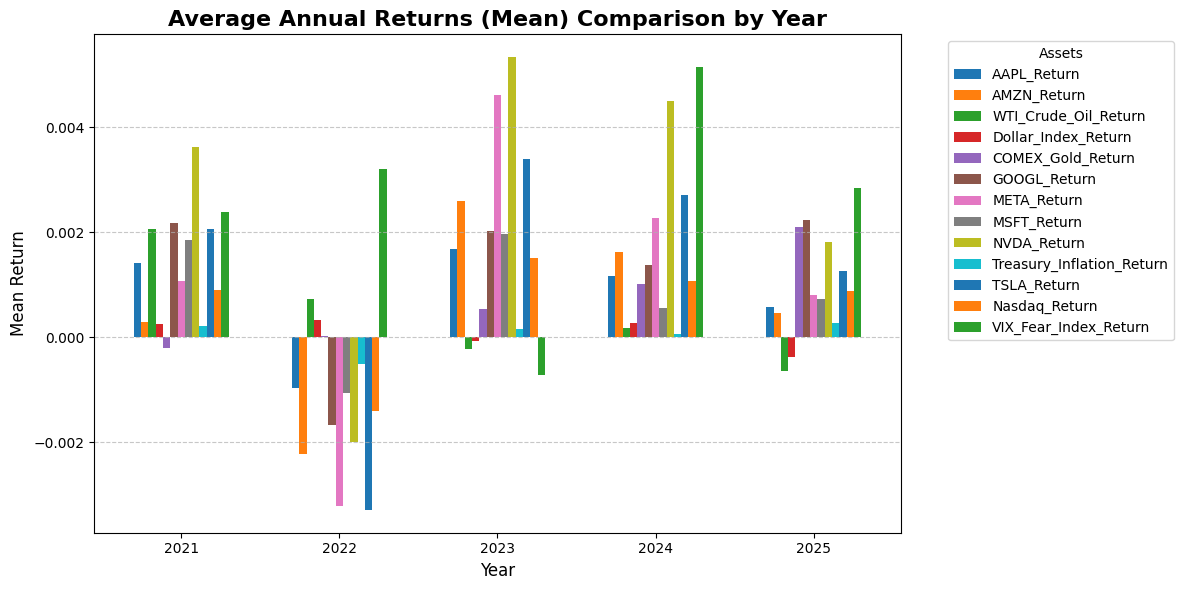

In [10]:
# Summary Mean Returns from Any Years
ax = df_GM.plot(kind='bar', figsize=(12, 6), width=0.6)

plt.title('Average Annual Returns (Mean) Comparison by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean Return', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Assets', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [11]:
# Summary Std Returns from Any Years 
df_GSD = df_returns.groupby('Year_Return').std()
df_GSD.drop(columns=['Date_Return'], inplace=True)
df_GSD

,AAPL_Return,AMZN_Return,WTI_Crude_Oil_Return,Dollar_Index_Return,COMEX_Gold_Return,GOOGL_Return,META_Return,MSFT_Return,NVDA_Return,Treasury_Inflation_Return,TSLA_Return,Nasdaq_Return,VIX_Fear_Index_Return
Year_Return,,,,,,,,,,,,,
2021,0.015758,0.015145,0.022108,0.003263,0.009250,0.015312,0.018633,0.013206,0.028396,0.002937,0.034504,0.011325,0.095972
2022,0.022487,0.031546,0.030343,0.005957,0.009768,0.024348,0.040478,0.022245,0.039823,0.005899,0.042002,0.020123,0.069310
2023,0.012788,0.020798,0.021350,0.004343,0.008341,0.019117,0.025121,0.015794,0.030507,0.004407,0.034049,0.010951,0.055171
2024,0.014287,0.017696,0.018171,0.003582,0.009433,0.017669,0.022983,0.012575,0.033074,0.002873,0.039998,0.011389,0.094383
2025,0.020396,0.021591,0.019752,0.004700,0.012871,0.020294,0.023847,0.015213,0.031129,0.002725,0.039828,0.015282,0.087114


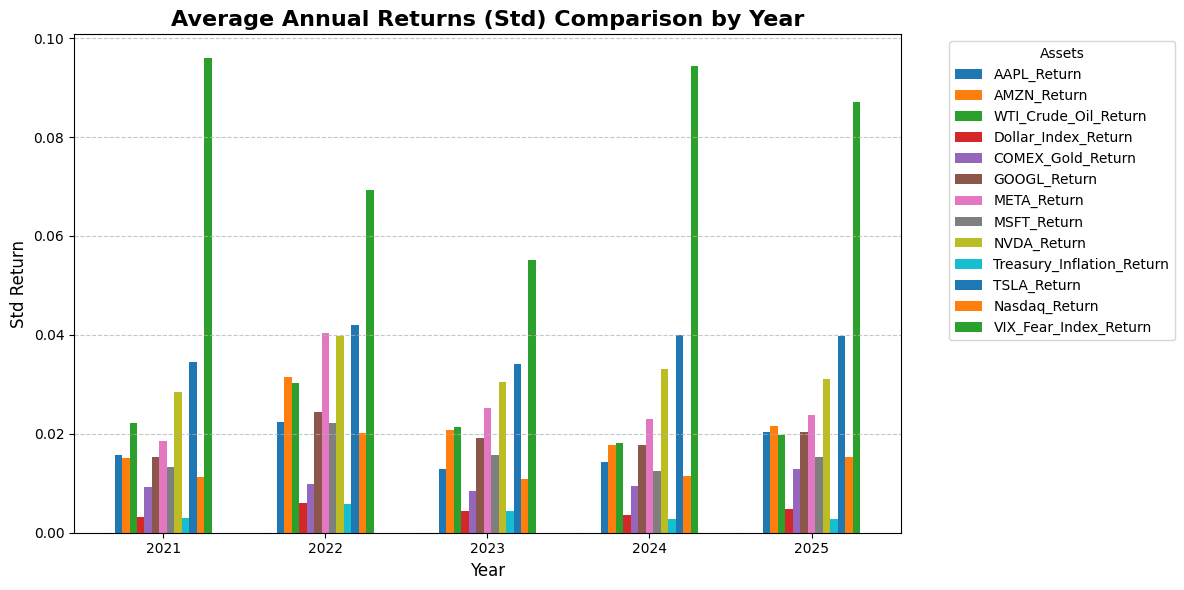

In [12]:
# Summary Mean Returns from Any Years
ax = df_GSD.plot(kind='bar', figsize=(12, 6), width=0.6)

plt.title('Average Annual Returns (Std) Comparison by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Std Return', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Assets', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Trend Visualization

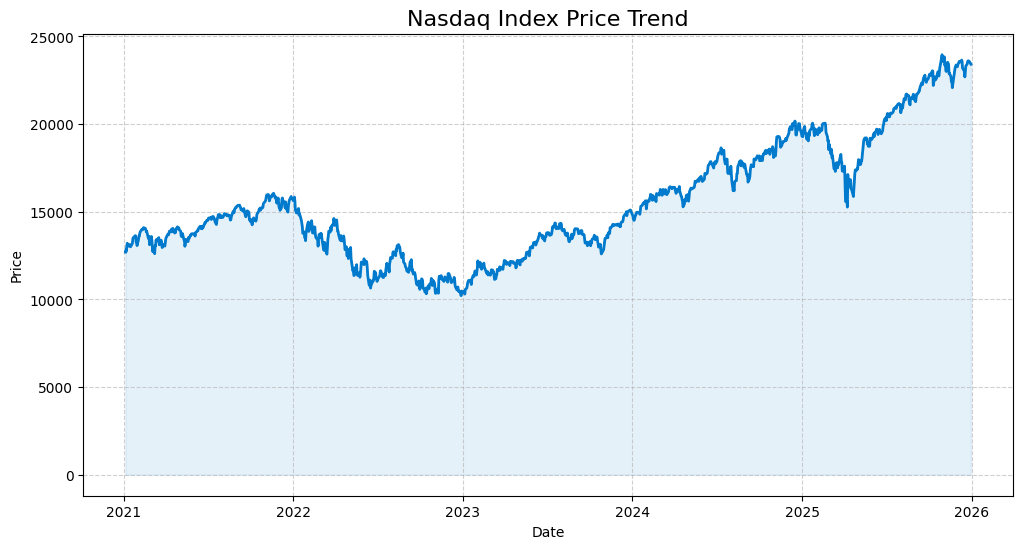

In [13]:
# Date to datetime
df['Date_Cleaned'] = pd.to_datetime(df['Date_Cleaned'])

plt.figure(figsize=(12, 6))
plt.plot(df['Date_Cleaned'], df['Nasdaq_Cleaned'], color='#007acc', linewidth=2)
plt.fill_between(df['Date_Cleaned'], df['Nasdaq_Cleaned'], color='#007acc', alpha=0.1)
plt.title('Nasdaq Index Price Trend', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

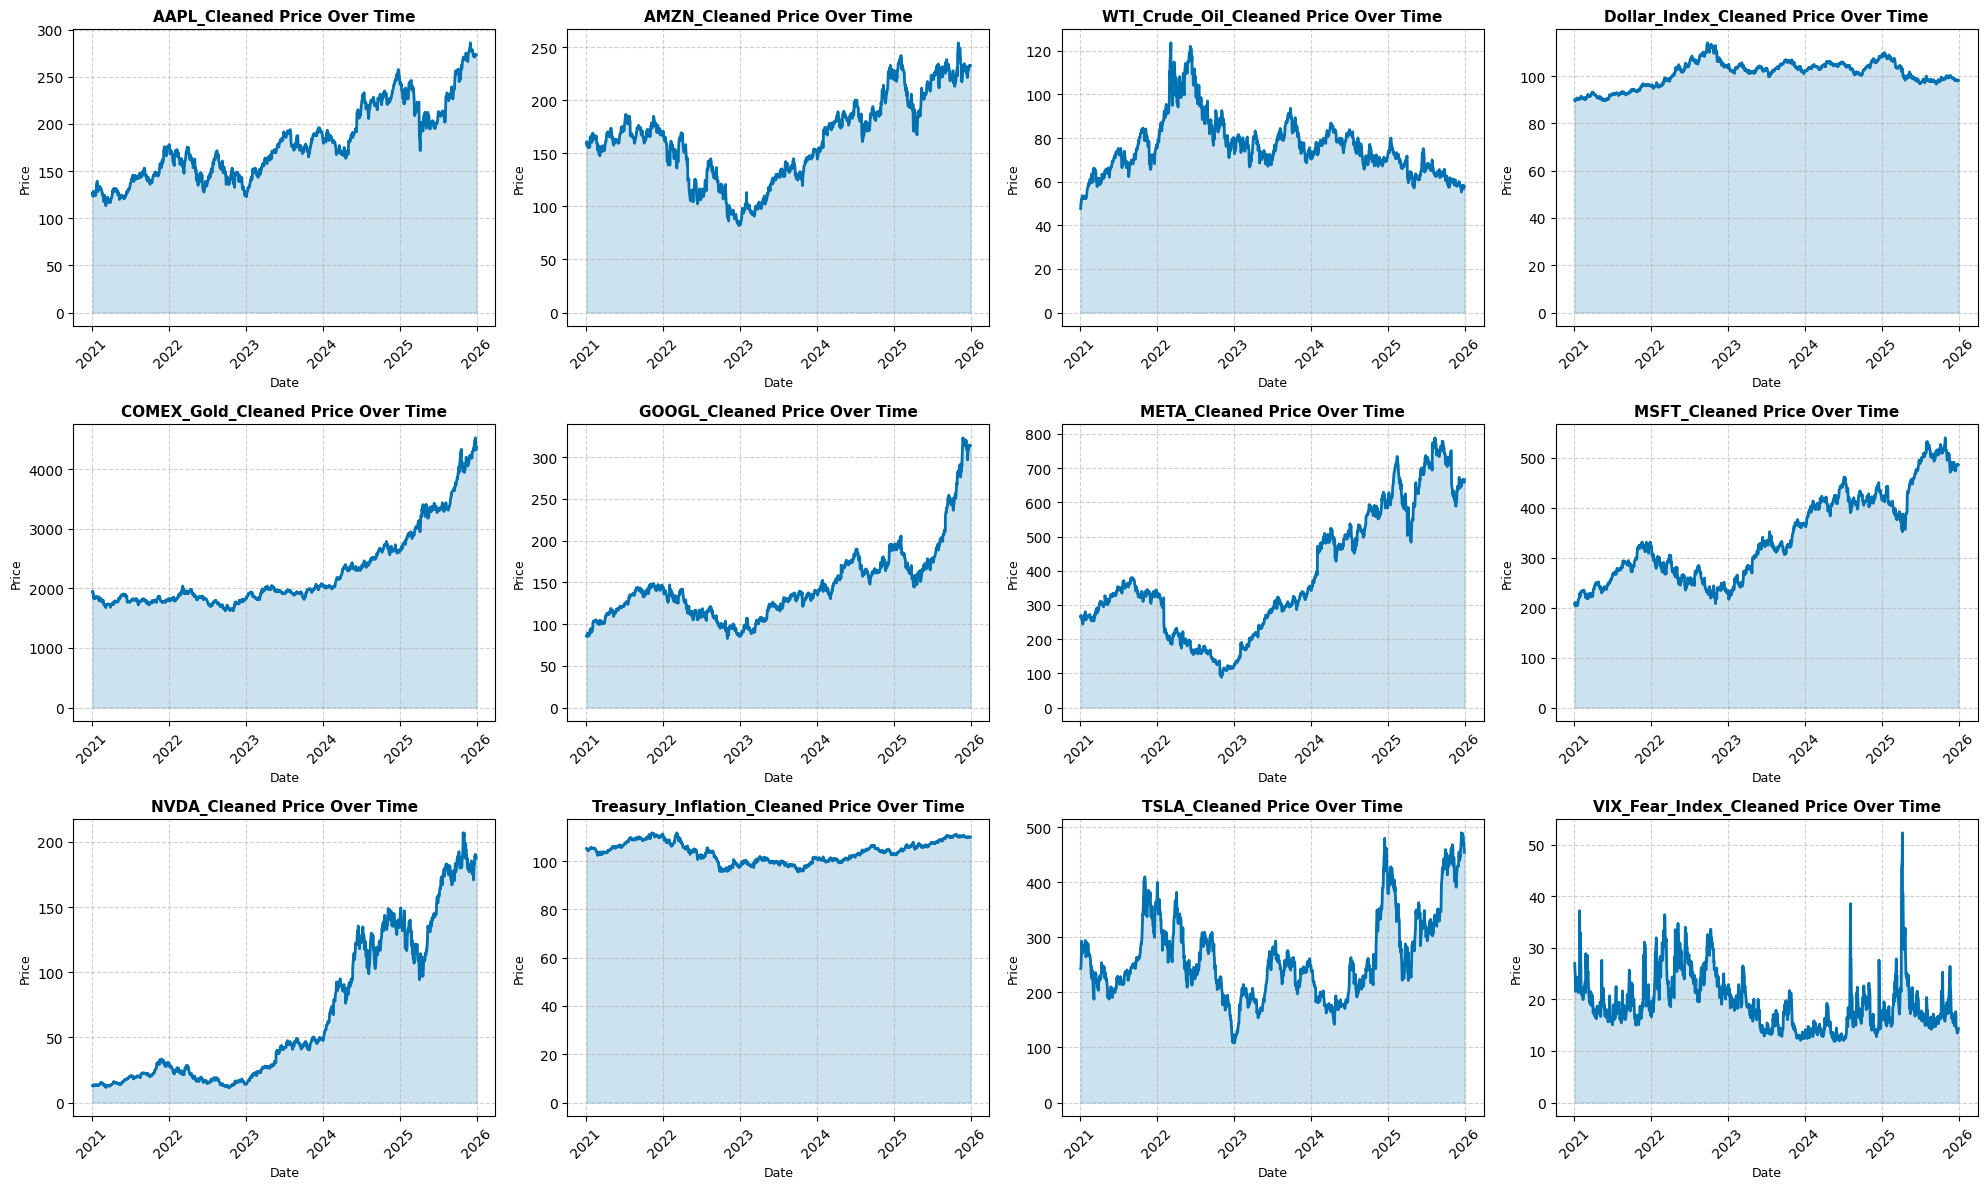

In [14]:
# Get all columns except Date
stocks = df.drop(columns=['Date_Cleaned','Nasdaq_Cleaned']).columns

# Create subplots - 3 rows x 4 columns
n_cols = 4
n_rows = (len(stocks) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()  # Flatten to 1D array for easier iteration

for idx, stock in enumerate(stocks):
    ax = axes[idx]
    ax.plot(df['Date_Cleaned'], df[stock], color='#0072B2', linewidth=2)
    ax.fill_between(df['Date_Cleaned'], df[stock], color='#0072B2', alpha=0.2)
    ax.set_title(f'{stock} Price Over Time', fontsize=11, fontweight='bold')
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Price', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=45)

# Hide any unused subplots
for idx in range(len(stocks), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


### Cumulative Return Visualization

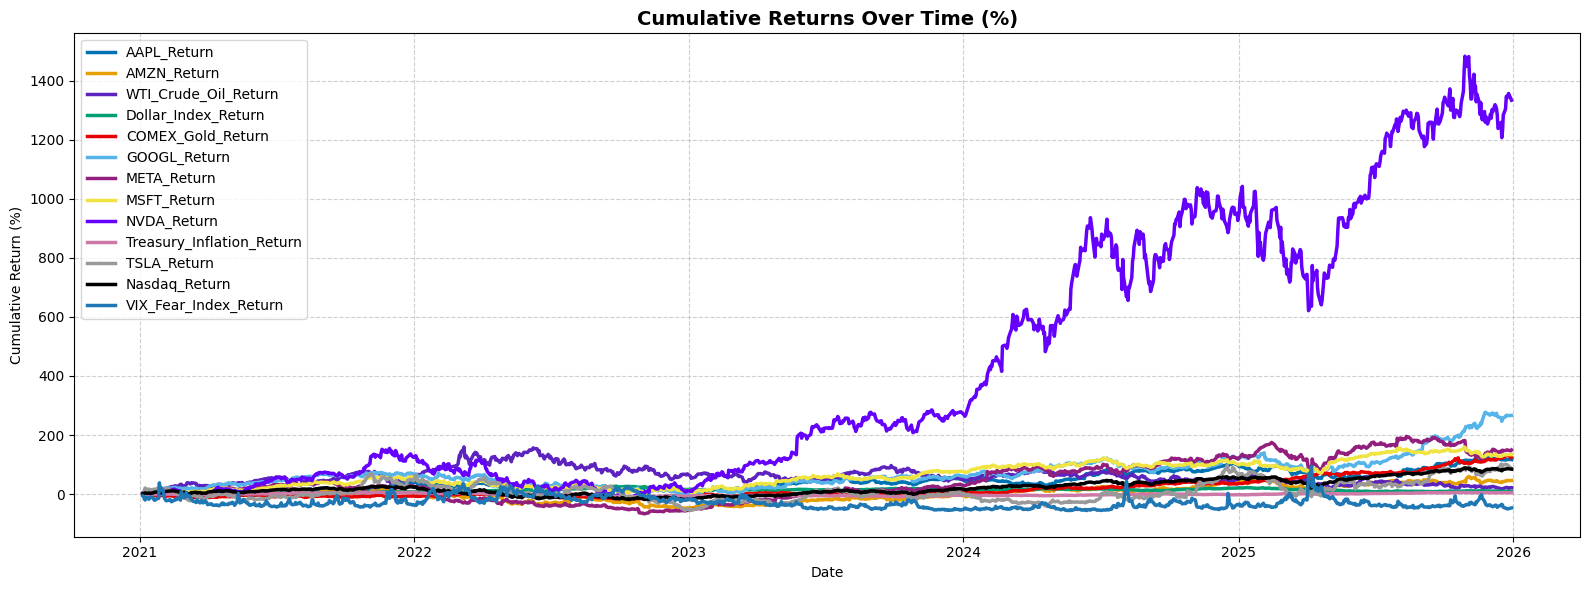

In [15]:
# Date column to datetime
df_returns['Date_Return'] = pd.to_datetime(df_returns['Date_Return'])

# Calculate Cumulative Returns
cumulative_returns = (1 + df_returns.drop(columns=['Date_Return'])).cumprod() - 1

# Get all columns except Date
stocks = df_returns.drop(columns=['Date_Return',"Year_Return"]).columns

# Okabe-Ito colorblind-friendly palette
okabe_ito_optimized = [
    '#0072B2',  # 1. Dark Blue (Cool/Dark)
    '#E69F00',  # 2. Orange (Warm/Medium)
    '#5C23BF',  # 3. Dark Purple (Warm/Dark)
    '#009E73',  # 4. Green (Cool/Medium)
    '#E60000',  # 5. Light Red (Warm/Light)
    '#56B4E9',  # 6. Blue (Cool/Light)
    '#921F7E',  # 7. Dark Magenta (Warm/Dark)
    '#F0E442',  # 8. Yellow (Warm/Medium)
    '#6400FB',  # 9. Light Purple (Warm/Light)
    '#CC79A7',  # 10. Pink (Warm/Light)
    '#999999',  # 11. Gray (Neutral - Use for less important data or background)
    '#000000'   # 12. Black (Neutral - Use for axes, labels, or important data points)
]
if len(stocks) > len(okabe_ito_optimized):
    extra_colors = [plt.cm.tab20(i) for i in range(len(stocks) - len(okabe_ito_optimized))]
    colors = okabe_ito_optimized + extra_colors
else:
    colors = okabe_ito_optimized[:len(stocks)]

# Plot cumulative returns for each stock
plt.figure(figsize=(16, 6))
for idx, stock in enumerate(stocks):
    plt.plot(df_returns['Date_Return'], cumulative_returns[stock] * 100, linewidth=2.5, label=stock, color=colors[idx])

plt.title('Cumulative Returns Over Time (%)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()


### Return Distribution Visualization

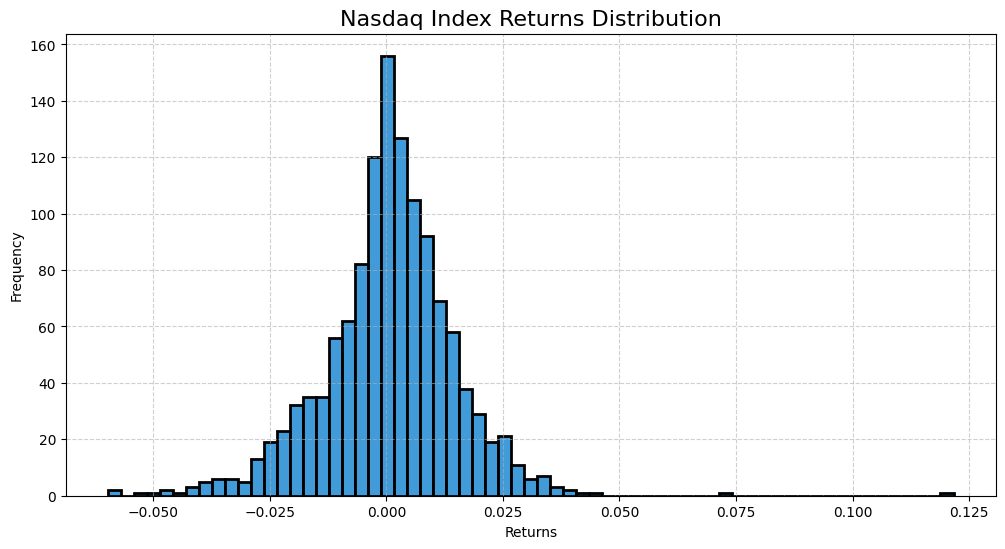

In [16]:
plt.figure(figsize=(12, 6))
sns.histplot(df_returns['Nasdaq_Return'], color='#007acc', linewidth=2)
plt.title('Nasdaq Index Returns Distribution', fontsize=16)
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

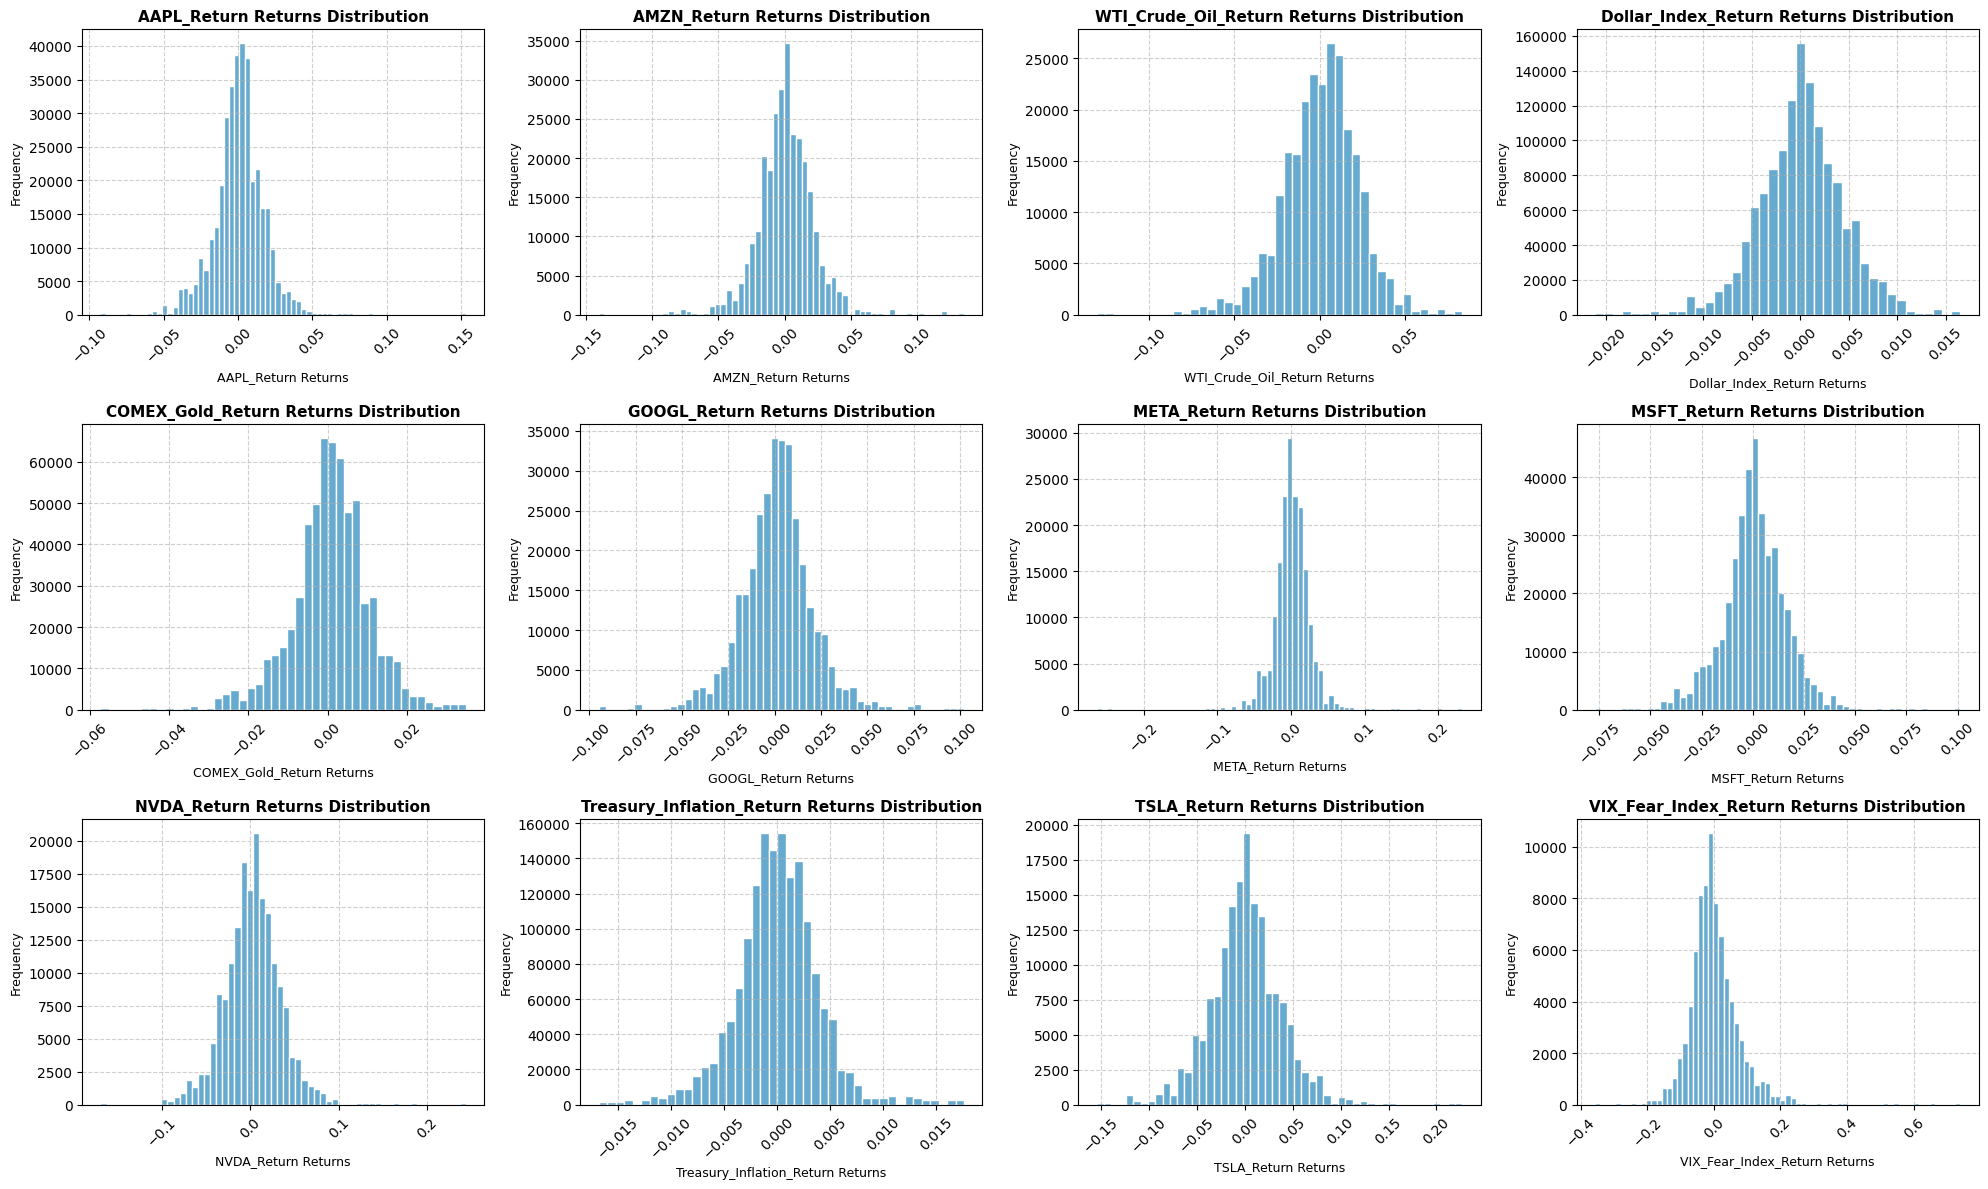

In [17]:
# Get all columns except Date for histogram plotting
stocks = df_returns.drop(columns=['Date_Return','Year_Return','Nasdaq_Return']).columns

# Create subplots - 3 rows x 4 columns
n_cols = 4
n_rows = (len(stocks) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()  # Flatten to 1D array for easier iteration

for idx, stock in enumerate(stocks):
    ax = axes[idx]
    sns.histplot(df_returns[stock], ax=ax, color='#0072B2', edgecolor='white', linewidth=1, stat='frequency', alpha=0.6)
    ax.set_title(f'{stock} Returns Distribution', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'{stock} Returns', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=45)

# Hide any unused subplots
for idx in range(len(stocks), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

### Return Overtime Visualization

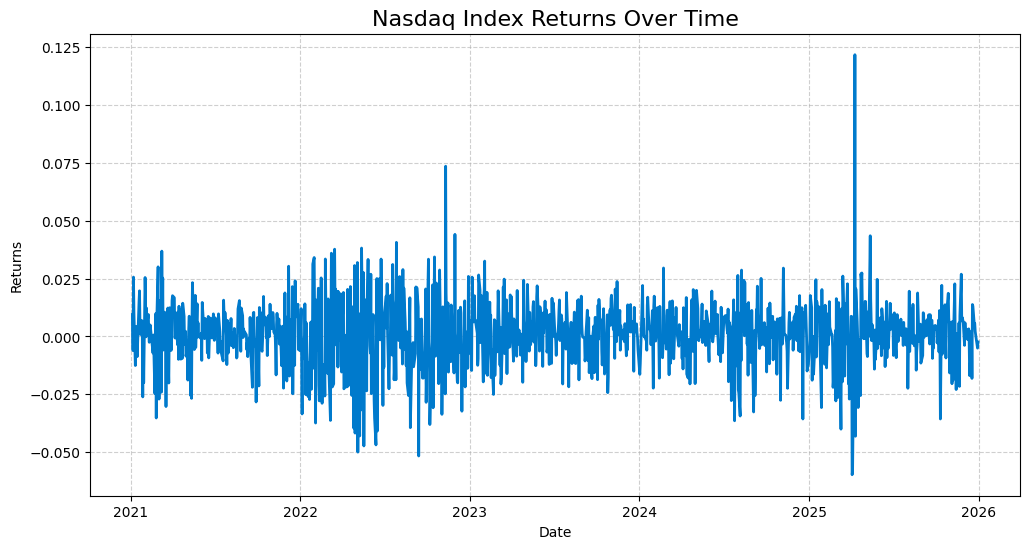

In [18]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date_Return', y='Nasdaq_Return', data=df_returns, color='#007acc', linewidth=2)
plt.title('Nasdaq Index Returns Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Returns')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

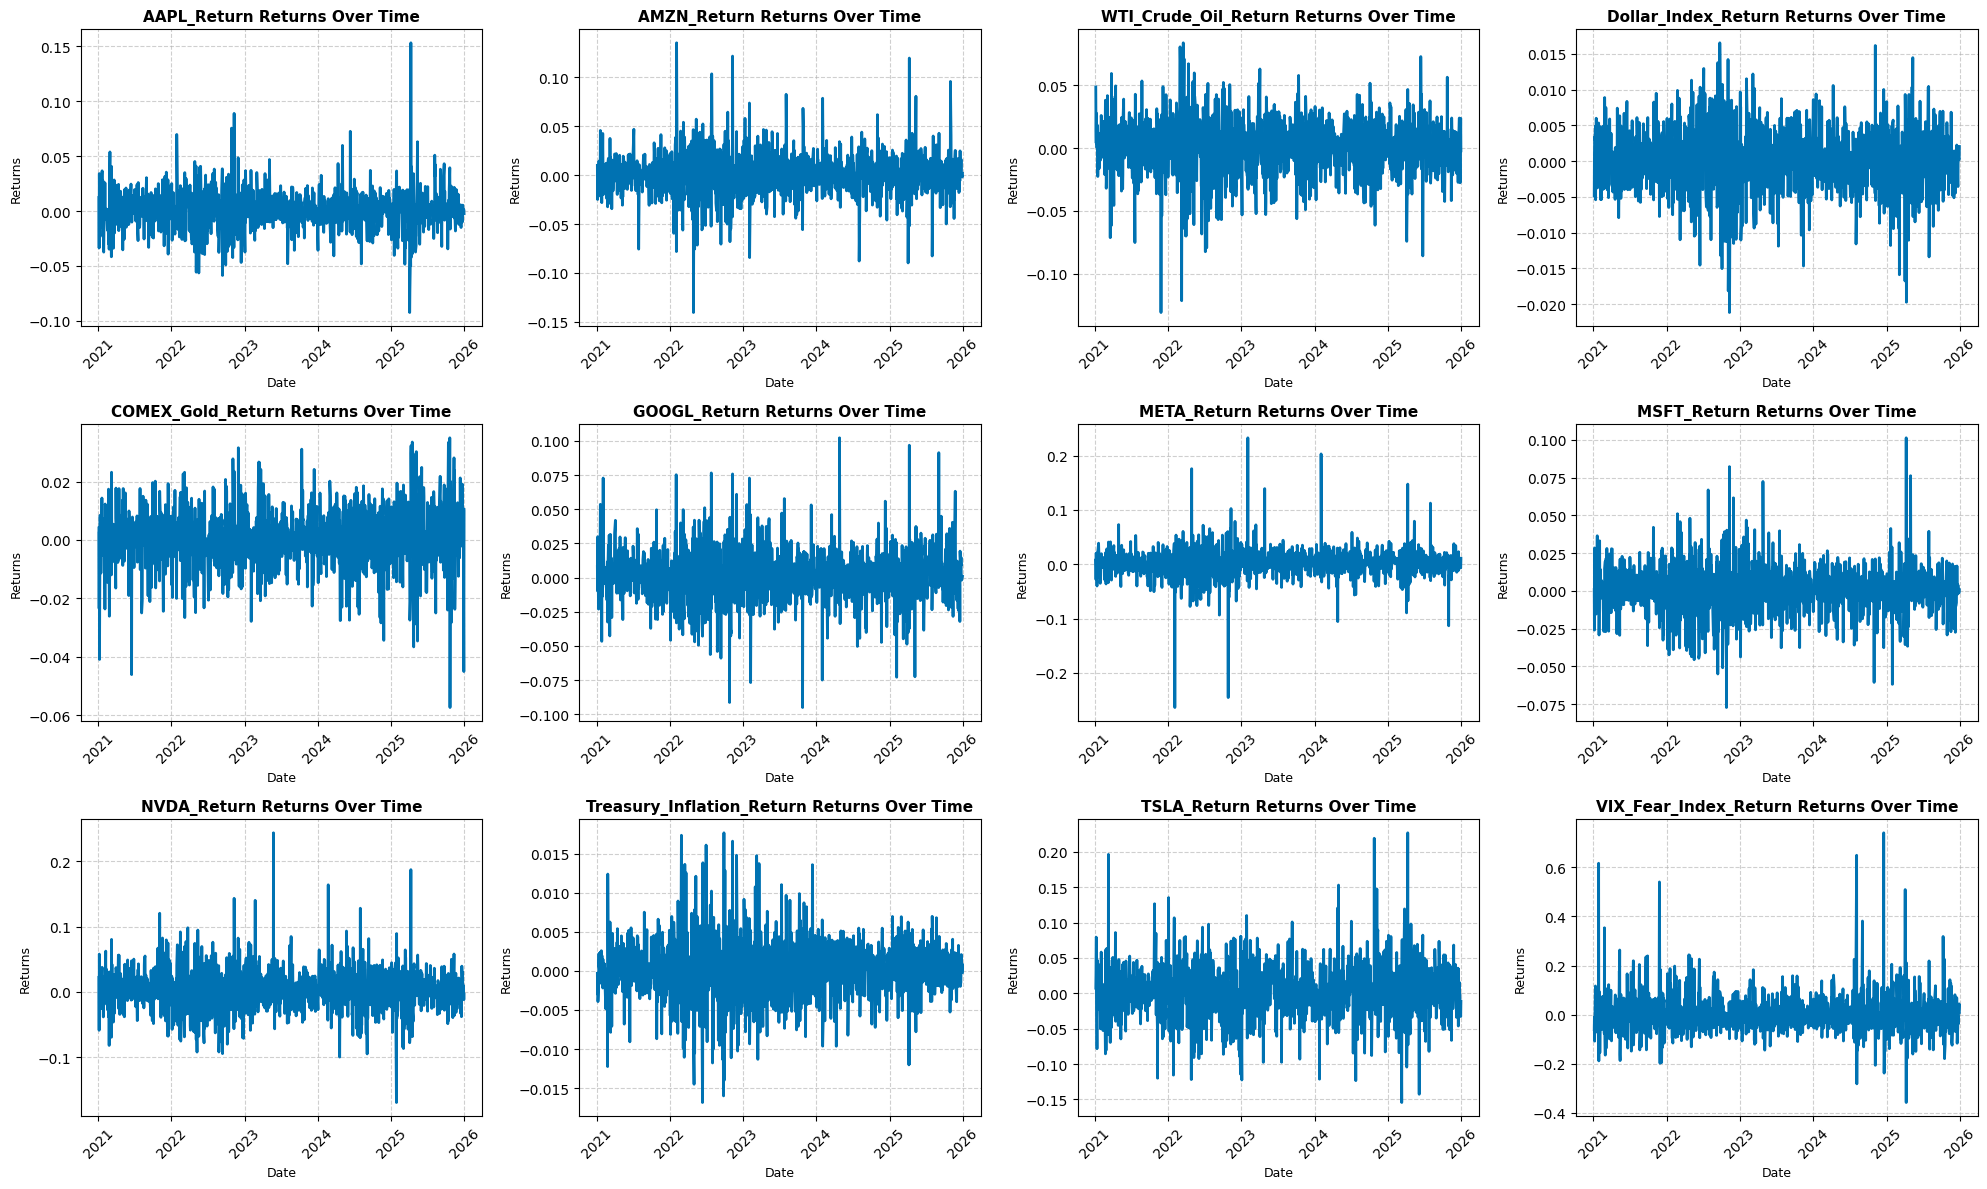

In [19]:
# Get all columns except Date
stocks = df_returns.drop(columns=['Date_Return','Year_Return','Nasdaq_Return']).columns

# Create subplots - 3 rows x 4 columns
n_cols = 4
n_rows = (len(stocks) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()  # Flatten to 1D array for easier iteration

for idx, stock in enumerate(stocks):
    ax = axes[idx]
    ax.plot(df_returns['Date_Return'], df_returns[stock], color='#0072B2', linewidth=2)
    ax.fill_between(df_returns['Date_Return'], df_returns[stock], color='#0072B2', alpha=0.2)
    ax.set_title(f'{stock} Returns Over Time', fontsize=11, fontweight='bold')
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Returns', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=45)

# Hide any unused subplots
for idx in range(len(stocks), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

### Percent Change By Years

In [20]:
df_filtered = df.loc[(df['Date_Cleaned'].dt.month == 12) & ((df['Date_Cleaned'].dt.day == 29) | (df['Date_Cleaned'].dt.day == 30) | (df['Date_Cleaned'].dt.day == 31))]
df_filtered

,Date_Cleaned,AAPL_Cleaned,AMZN_Cleaned,WTI_Crude_Oil_Cleaned,Dollar_Index_Cleaned,COMEX_Gold_Cleaned,GOOGL_Cleaned,META_Cleaned,MSFT_Cleaned,NVDA_Cleaned,Treasury_Inflation_Cleaned,TSLA_Cleaned,Nasdaq_Cleaned,VIX_Fear_Index_Cleaned
249,2021-12-29,175.530121,169.201004,76.559998,95.930000,1805.099976,145.555237,340.561096,330.111572,29.942995,110.757133,362.063324,15766.219727,16.950001
250,2021-12-30,174.375443,168.644501,76.989998,95.970001,1812.699951,145.104141,341.971222,327.572601,29.528799,111.333786,356.779999,15741.559570,17.330000
251,2021-12-31,173.758972,166.716995,75.209999,95.669998,1827.500000,143.765747,334.016815,324.676453,29.354134,111.196068,352.260010,15644.969727,17.219999
501,2022-12-29,127.564354,84.180000,78.400002,103.839996,1819.500000,87.786713,119.425789,234.846222,14.588395,97.853920,121.820000,10478.089844,21.440001
502,2022-12-30,127.879303,84.000000,80.260002,103.519997,1819.699951,87.568359,119.505211,233.686676,14.599387,97.560631,123.180000,10466.480469,21.670000
752,2023-12-29,190.550476,151.940002,71.650002,101.330002,2062.399902,138.642471,351.504578,369.671875,49.494431,101.272659,248.479996,15011.349609,12.450000
1003,2024-12-30,250.829803,221.300003,70.989998,108.129997,2606.100098,190.493942,589.381409,420.758698,137.452393,103.071564,417.410004,19486.789062,17.400000
1004,2024-12-31,249.059464,219.389999,71.720001,108.489998,2629.199951,188.561508,583.669495,417.460632,134.253281,102.945969,403.839996,19310.789062,17.350000
1255,2025-12-29,273.504089,232.070007,58.080002,98.040001,4325.100098,313.559998,658.690002,485.990753,188.220001,110.150002,459.640015,23474.349609,14.200000
1256,2025-12-30,272.824707,232.529999,57.950001,98.239998,4370.100098,313.850006,665.950012,486.369904,187.539993,110.129997,454.429993,23419.080078,14.330000


In [21]:
df_Last_day = df[df['Date_Cleaned'].dt.strftime('%Y-%m-%d').isin(['2021-12-31', '2022-12-30', '2023-12-29', '2024-12-31', '2025-12-30'])]
df_Last_day

,Date_Cleaned,AAPL_Cleaned,AMZN_Cleaned,WTI_Crude_Oil_Cleaned,Dollar_Index_Cleaned,COMEX_Gold_Cleaned,GOOGL_Cleaned,META_Cleaned,MSFT_Cleaned,NVDA_Cleaned,Treasury_Inflation_Cleaned,TSLA_Cleaned,Nasdaq_Cleaned,VIX_Fear_Index_Cleaned
251,2021-12-31,173.758972,166.716995,75.209999,95.669998,1827.500000,143.765747,334.016815,324.676453,29.354134,111.196068,352.260010,15644.969727,17.219999
502,2022-12-30,127.879303,84.000000,80.260002,103.519997,1819.699951,87.568359,119.505211,233.686676,14.599387,97.560631,123.180000,10466.480469,21.670000
752,2023-12-29,190.550476,151.940002,71.650002,101.330002,2062.399902,138.642471,351.504578,369.671875,49.494431,101.272659,248.479996,15011.349609,12.450000
1004,2024-12-31,249.059464,219.389999,71.720001,108.489998,2629.199951,188.561508,583.669495,417.460632,134.253281,102.945969,403.839996,19310.789062,17.350000
1256,2025-12-30,272.824707,232.529999,57.950001,98.239998,4370.100098,313.850006,665.950012,486.369904,187.539993,110.129997,454.429993,23419.080078,14.330000


In [22]:
# Extract years and prices for the last trading day of December
years = pd.to_datetime(df_Last_day['Date_Cleaned']).dt.year.astype(str)
prices = df_Last_day['Nasdaq_Cleaned']

# Calculate percentage change
percent_change = df_Last_day['Nasdaq_Cleaned'].pct_change() * 100

# Create a DataFrame to hold the metrics
metrics = {
    'Year': years, 
    'Price': prices, 
    'Percent Change': percent_change
}

metrics_df = pd.DataFrame(metrics)
metrics_df['Price'] = metrics_df['Price'].map('{:,.2f}'.format)
metrics_df['Percent Change'] = metrics_df['Percent Change'].apply(
    lambda x: '-' if pd.isna(x) else f'{x:+.2f}%'
)

# Display the metrics in a markdown table format
print(metrics_df.to_markdown(index=False))

|   Year | Price     | Percent Change   |
|-------:|:----------|:-----------------|
|   2021 | 15,644.97 | -                |
|   2022 | 10,466.48 | -33.10%          |
|   2023 | 15,011.35 | +43.42%          |
|   2024 | 19,310.79 | +28.64%          |
|   2025 | 23,419.08 | +21.27%          |


In [23]:
metrics_df = metrics_df[['Year', 'Price', 'Percent Change']]
metrics_df.to_csv("metrics_output.csv", index=False)
print(f"Complete to save CSV: metrics_output.csv")

Complete to save CSV: metrics_output.csv


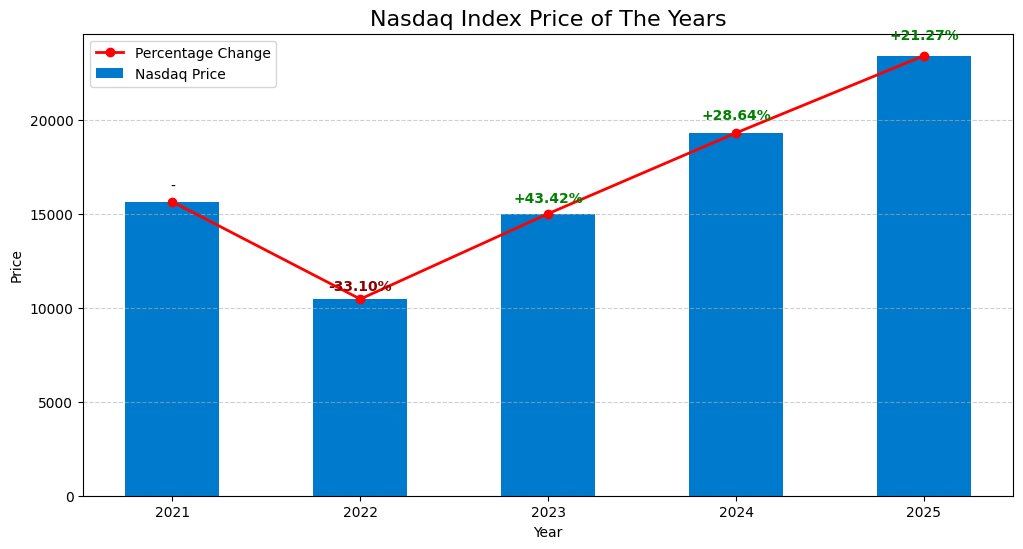

In [24]:
plt.figure(figsize=(12, 6))
# Percent change annotations
for i in range(len(years)):
    x_pos = years.iloc[i]
    y_pos = prices.iloc[i]
    pct = percent_change.iloc[i]
    
    if pd.isna(pct):
        plt.text(x_pos, y_pos + (y_pos * 0.03), '-', ha='center', va='bottom', fontsize=10)
    else:
        text_color = 'green' if pct > 0 else 'Darkred'
        plt.text(x_pos, y_pos + (y_pos * 0.03), f'{pct:+.2f}%', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color=text_color)


# Create bar chart and line plot
plt.bar(years, prices, color='#007acc', width=0.5, label='Nasdaq Price')
plt.plot(years, prices, color='red', marker='o', linestyle='-', linewidth=2, label='Percentage Change')

plt.title('Nasdaq Index Price of The Years', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

plt.show()

In [25]:
Asset = ['AAPL_Cleaned', 'AMZN_Cleaned', 'Dollar_Index_Cleaned', 'GOOGL_Cleaned', 'META_Cleaned', 'MSFT_Cleaned', 'NVDA_Cleaned', 'TSLA_Cleaned', 'WTI_Crude_Oil_Cleaned','COMEX_Gold_Cleaned','Nasdaq_Cleaned']

# Calculate Mean, Std, and Risk-Adjusted Return
mean_ret = df[Asset].mean()
std_ret = df[Asset].std()
risk_adj = mean_ret / std_ret

# Create a DataFrame to display the results and sort by Risk-Adjusted Return
stats_df = pd.DataFrame({
    'Mean (Return)': mean_ret,
    'Std (Risk)': std_ret,
    'Risk_Adjusted_Return': risk_adj
}).sort_values(by='Risk_Adjusted_Return', ascending=False)

# Display the Risk-Adjusted Return sorted from high to low
print("=== Risk-Adjusted Return (Mean / Std) ===")
stats_df

=== Risk-Adjusted Return (Mean / Std) ===


,Mean (Return),Std (Risk),Risk_Adjusted_Return
Dollar_Index_Cleaned,100.990835,5.439877,18.564910
WTI_Crude_Oil_Cleaned,76.092832,12.950562,5.875639
Nasdaq_Cleaned,15466.758222,3360.473168,4.602554
AAPL_Cleaned,179.388218,39.990199,4.485805
AMZN_Cleaned,163.474199,40.352608,4.051143
MSFT_Cleaned,342.100633,89.202662,3.835094
TSLA_Cleaned,265.618361,77.052813,3.447225
COMEX_Gold_Cleaned,2275.714715,669.532545,3.398961
GOOGL_Cleaned,145.596341,45.526542,3.198054
META_Cleaned,386.845488,186.866014,2.070176


### Risk-Adjusted Return

C:\Temp\ipykernel_32804\3567005377.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=stats_df['Risk_Adjusted_Return'], y=stats_df.index, palette='RdYlGn')


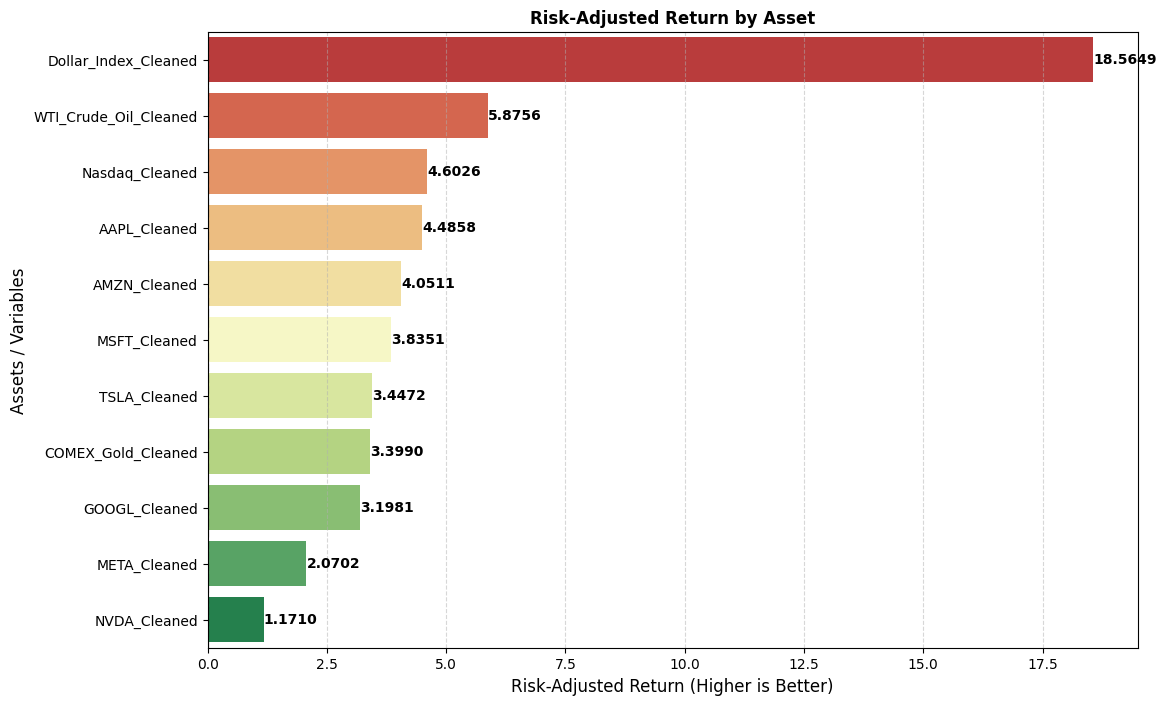

In [26]:
# Visalize the plot
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=stats_df['Risk_Adjusted_Return'], y=stats_df.index, palette='RdYlGn')

# Text annotations at the end of each bar
for i, v in enumerate(stats_df['Risk_Adjusted_Return']):
    offset = 0.005 if v > 0 else -0.015
    ax.text(v + offset, i, f"{v:.4f}", color='black', va='center', fontweight='bold')

plt.axvline(0, color='black', linewidth=1.5, linestyle='--')
plt.title('Risk-Adjusted Return by Asset', fontsize=12, fontweight='bold')
plt.xlabel('Risk-Adjusted Return (Higher is Better)', fontsize=12)
plt.ylabel('Assets / Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()